# Example: Controllability Analysis (Part 3)

- Author: Parker Smith
- Date: 2/8/2026

## Introduction

This problem explores how different $R$ values can be used to train the Controllability Gramian, which can produce different optimal control solutions

## Problem

Let the states be $x = [x_1, x_2]$, where $x_1$ represents the position/angle of the first oscillator and $x_2$ represents the position/angle of the second oscillator. In state-space form, the true dynamics is

$$
\begin{aligned}
\dot{x}_1 &= -\omega_1^2 x_1 + k(x_2 - x_1) + u_1 \\
\dot{x}_2 &= -\omega_2^2 x_2 + k(x_1 - x_2) + u_2
\end{aligned}
$$

where $\omega_1 = 2.0$ and $\omega_2 = 3.0$ are the natural frequencies of the two oscillators, $k = 0.5$ is the coupling strength, and $u_1, u_2$ represent the control inputs applied to each oscillator respectively.

First, we import some packages:

In [1]:
# Import packages:
import matplotlib.pyplot as plt
import numpy as np
import torch
from dymad.io import load_model
from dymad.models import KBF
from dymad.training import NODETrainer, WeakFormTrainer
from dymad.utils import plot_summary, plot_trajectory, TrajectorySampler
from funcs import *
import time

Next, setup the trainer:

In [2]:
# Parameters:
B = 300
N = 301
t_grid = np.linspace(0, 6, N)

# System parameters for coupled oscillator with damping control:
omega1 = 2.0
omega2 = 3.0
k_coupling = 0.5

# Helper function:
def f_ctrl(t, x, u):
    x1, x2 = x[0], x[1]

    dx1 = -omega1**2 * x1 + k_coupling * (x2 - x1) + u[0]
    dx2 = -omega2**2 * x2 + k_coupling * (x1 - x2) + u[1]

    return np.array([dx1, dx2])

# Options for KBF:
mdl_kb = {
    "encoder_layers": 3,
    "decoder_layers": 3,
    "hidden_dimension": 48,
    "koopman_dimension": 8,
    "activation": "prelu",
    "weight_init": "xavier_uniform"}
crit = {
    "dynamics": {"weight": 2.0},
    "recon": {"weight": 1.0}}
trn_wf = {
    "n_epochs": 1500,
    "save_interval": 50,
    "load_checkpoint": False,
    "learning_rate": 3e-3,
    "decay_rate": 0.9995,
    "weak_form_params": {
        "N": 13,
        "dN": 3,
        "ordpol": 3,
        "ordint": 3}}

# Set config:
config_path = 'ctrl_model.yaml'
mdl_cat = {
    "name": "ctrl_coupled",
    "autoencoder_type": "cat"}
mdl_cat.update(**mdl_kb)

Generate sample trajectories for training:

In [3]:
# Sample trajectories:
sampler = TrajectorySampler(f_ctrl, config='ctrl_data.yaml')
ts, xs, us, ys = sampler.sample(t_grid, batch=B, save='./data/kp_ctrl_coupled.npz')

And train:

In [4]:
# trainer = WeakFormTrainer(config_path, KBF, config_mod={"model": mdl_cat, "criterion": crit, "training": trn_wf})
# trainer.train()

And check the model convergence:

array([<Axes: ylabel='State 1'>, <Axes: ylabel='State 2'>,
       <Axes: ylabel='Control 1'>,
       <Axes: xlabel='Time', ylabel='Control 2'>], dtype=object)

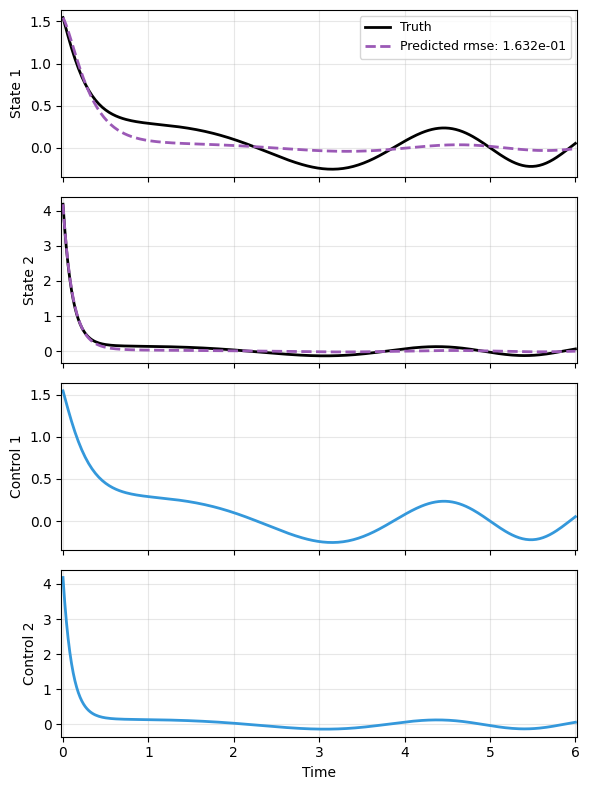

In [5]:
# Parameters:
B = 300
N = 301
t_grid = np.linspace(0, 6, N)

# Sample a trajectory:
sampler = TrajectorySampler(f_ctrl, config='ctrl_data.yaml')
ts, xs, ys, us = sampler.sample(t_grid, batch=1)
x_data = xs[0]
t_data = ts[0]
u_data = us[0]

# The variation:
model, prd_func = load_model(KBF, f'ctrl_coupled.pt')
with torch.no_grad():
    pred_cat = prd_func(x_data, t_data, u=u_data)
res = [x_data, pred_cat]

# Plot comparison:
labels = ['Truth', 'Predicted']
plot_trajectory(np.array(res), t_data, "KP", labels=labels, us=u_data, ifclose=False)

Next, we can linearize the system:

In [6]:
# Load model:
model, prd_func = load_model(KBF, f'ctrl_coupled.pt')

# Get system matrices linearized around equilibrium (trim) condition:
x_ref = np.array([0, 0])
u_ref = np.array([0, 0])
A, B, C = linearize(model, x_ref, u_ref)

# Discretize:
dt = t_grid[1] - t_grid[0]
A, B = discretize_system(A[0], B[0], dt)

# Grab the first matrices for C:
C = C[0]

And compare against the trainer data:

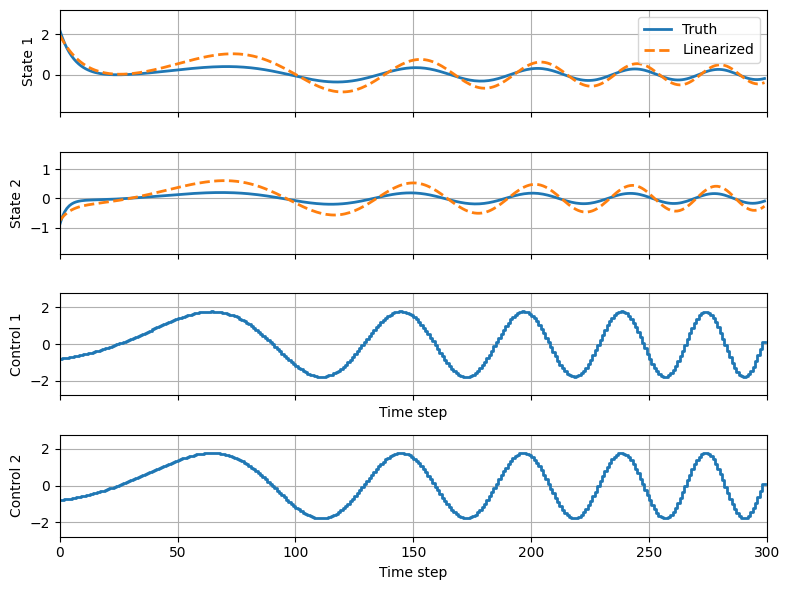

In [7]:
# Sample one random trajectory:
N = 300
t_grid = np.linspace(0, 10, N)
sampler = TrajectorySampler(f_ctrl, config='ctrl_data.yaml')
ts, xs, us, ys = sampler.sample(t_grid, batch=1)

# Extract data:
x_true = xs[0]
t_data = ts[0]
u_data = us[0]
x0 = x_true[0]
n_tsteps = len(x_true) - 1

# Linearized prediction:
x_linear, _ = prop_dyn_latent(model, A, B, C, x0, u_seq=u_data)

# Plot comparison:
plot_traj(np.stack([x_true.T, x_linear[1:].T], axis=-1), u_data, N, lab=["Truth", "Linearized"], line=["-", "--"])

Confirm stability and controllability:

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.



Eigenvalues and magnitudes:
--------------------------------------------------
λ_1 =  0.56851 +  0.00000j  |λ| = 0.56851
λ_2 =  0.82705 +  0.00000j  |λ| = 0.82705
λ_3 =  0.99996 +  0.00000j  |λ| = 0.99996
λ_4 =  0.98039 +  0.00000j  |λ| = 0.98039
λ_5 =  0.91485 +  0.00000j  |λ| = 0.91485
λ_6 =  0.92534 +  0.01716j  |λ| = 0.92550
λ_7 =  0.92534 + -0.01716j  |λ| = 0.92550
λ_8 =  0.93963 +  0.00000j  |λ| = 0.93963
--------------------------------------------------
LATENT SPACE IS FULLY CONTROLLABLE, BUT THE OBSERVATION SPACE IS NOT


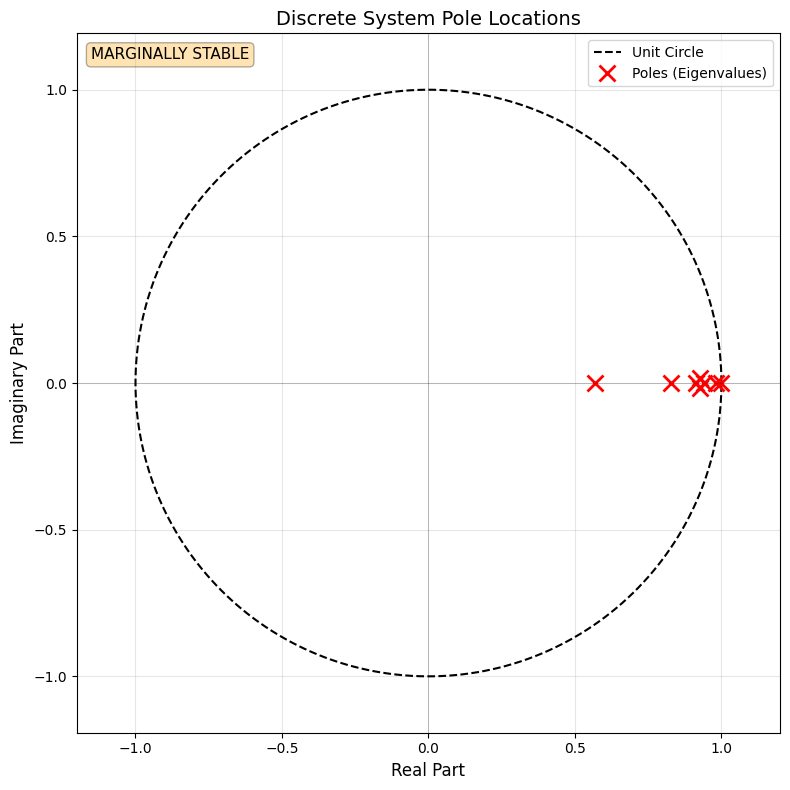

In [8]:
# Check for stability:
n_tsteps = 500
eigs = np.linalg.eigvals(A)

# Calculate Controllability matrix & Gramian for latent space:
_, W_c = controllability(A, B, n_tsteps)
rank_latent = np.linalg.matrix_rank(W_c)

# Check Input-Output Gramain and find rank:
W_io = input_output(A, B, C, n_tsteps)
rank_obs = np.linalg.matrix_rank(W_io)

# Stability analysis:
_, plot_poles(A)

# Print results for controllability:
if rank_latent == A.shape[0] and rank_obs == C.shape[0]:
    print(f"LATENT AND OBSERVATION SPACE ARE FULLY CONTROLLABLE")
elif rank_latent == A.shape[0] and rank_obs != C.shape[0]:
    print(f"LATENT SPACE IS FULLY CONTROLLABLE, BUT THE OBSERVATION SPACE IS NOT")
else:
    print(f"NEITHER THE LATENT NOR OBSERVATION SPACE ARE FULLY CONTROLLABLE")

Next, we can show how altering R (and thus the Controllability Gramian) can change the optimal solution we receive:

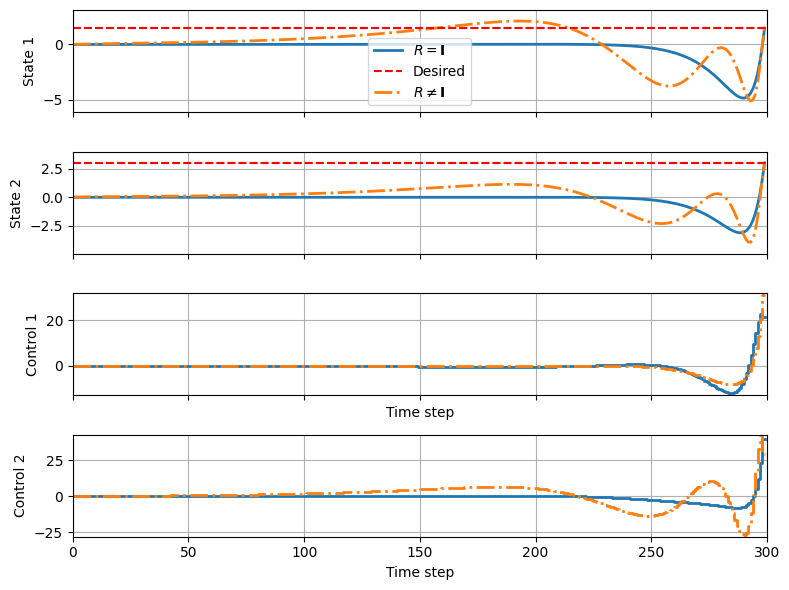

In [9]:
# Problem settings:
x_f = np.array([1.5, 3]).T
x_0 = np.array([0, 0]).T
n_tsteps = 300

# Define R for control cost:
R = np.eye(B.shape[1])

# Recompute controllability:
Ctrl, W_c = weighted_controllability(A, B, R, n_tsteps)

# Solve for control sequence using normal controllability:
x_ctr, u_ctr = optimal_ctrl(A, B, C, model, Ctrl, W_c, n_tsteps, x_0, x_f, plot_graph=False)

# Change weights:
R[:, 0] *= 50

# Compute again with the weighted controllability:
Ctrl, W_c = weighted_controllability(A, B, R, n_tsteps)
x_ctr_2, u_ctr_2 = optimal_ctrl(A, B, C, model, Ctrl, W_c, n_tsteps, x_0, x_f, plot_graph=False)

# Plot trajectories:
plot_traj(np.stack([x_ctr[1:].T, x_ctr_2[1:].T], axis=-1), np.stack([u_ctr, u_ctr_2], axis=-1), n_tsteps, x_f, lab=[r'$R = \mathbf{I}$', r'$R \ne \mathbf{I}$'], line=['-','-.'])

As you can see, this penalizes the first control more and, thus, leverages the second control more to achieve the state.

Next, we will compare against Riccati as we did in Part 1. To do so, we will use a soft (but heavily weighted) constraint to penalize deviation from the final condition:

Controllability: Cost = 41974.088, Endpoint error = 2.15e-02
Riccati:         Cost = 41374.891, Endpoint error = 2.26e-02
Controllability is faster by a factor of 386.2!


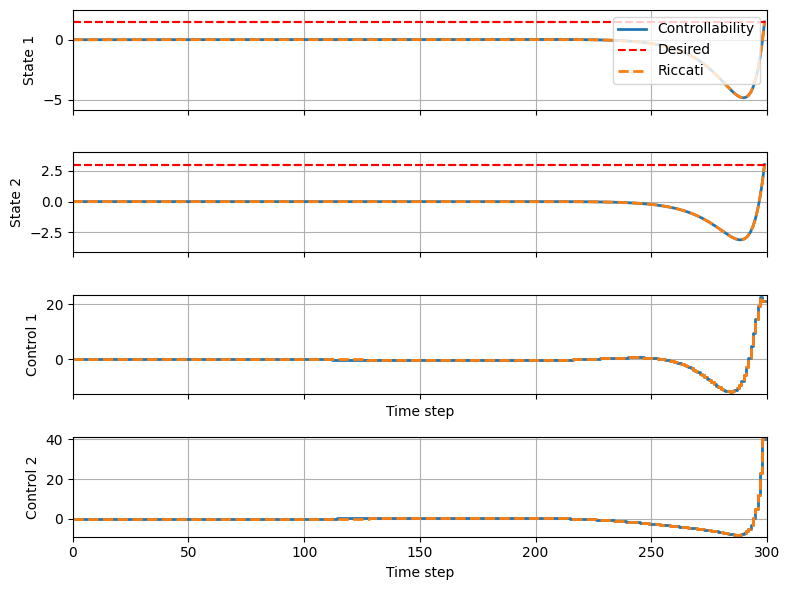

In [10]:
# Problem settings:
x_f = np.array([1.5, 3]).T
x_0 = np.array([0, 0]).T
n_tsteps = 300

# Define R for control cost (unweighted):
R = np.eye(B.shape[1])

# Define Q for state cost (latent space):
Q = 1e-8 * np.eye(A.shape[0])

# Compute controllability:
Ctrl, W_c = weighted_controllability(A, B, R, n_tsteps)

# Solve for control sequence using controllability:
start_time_ctr = time.time()
x_ctr, u_ctr = optimal_ctrl(A, B, C, model, Ctrl, W_c, n_tsteps, x_0, x_f, plot_graph=False)
end_time_ctr = time.time()
elapsed_ctr = end_time_ctr - start_time_ctr

# Solve using Riccati with feasible hard constraint:
start_time_ric = time.time()
x_ric, u_ric = riccati_opt_soft(A, B, C, model, x_0, x_f, n_tsteps, Q, R, terminal_weight=1e12)
end_time_ric = time.time()
elapsed_ric = end_time_ric - start_time_ric

# Plot comparison:
plot_traj(
    np.stack([x_ctr[1:].T, x_ric[1:].T], axis=-1),
    np.stack([u_ctr, u_ric], axis=-1),
    n_tsteps,
    x_f,
    lab=['Controllability', 'Riccati'],
    line=['-', '--']
)

# Compute costs:
cost_ctr = np.sum(u_ctr @ R @ u_ctr.T)
cost_ric = np.sum(u_ric @ R @ u_ric.T)

# Print results:
print(f"Controllability: Cost = {cost_ctr:.3f}, Endpoint error = {np.linalg.norm(x_ctr[-1, :] - x_f):.2e}")
print(f"Riccati:         Cost = {cost_ric:.3f}, Endpoint error = {np.linalg.norm(x_ric[-1, :] - x_f):.2e}")
print(f"Controllability is faster by a factor of {elapsed_ric / elapsed_ctr:.1f}!")

Now, we will change the weight on the first control and re-run the comparison:

Controllability: Cost = 865612.249, Endpoint error = 4.21e-03
Riccati:         Cost = 701111.396, Endpoint error = 2.26e-02
Controllability is faster by a factor of 75.3!


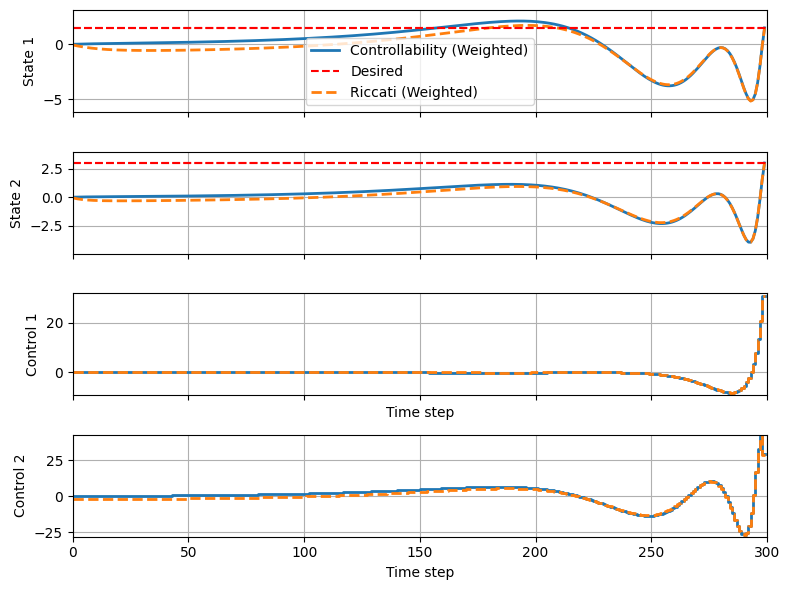

In [11]:
# Problem settings (same as before):
x_f = np.array([1.5, 3]).T
x_0 = np.array([0, 0]).T
n_tsteps = 300

# Define R for control cost (weighted):
R_weighted = np.eye(B.shape[1])
R_weighted[0, 0] *= 50  # Penalize first control more

# Define Q for state cost (latent space):
Q = 1e-8 * np.eye(A.shape[0])

# Compute weighted controllability:
Ctrl_w, W_c_w = weighted_controllability(A, B, R_weighted, n_tsteps)

# Solve for control sequence using weighted controllability:
start_time_ctr = time.time()
x_ctr_w, u_ctr_w = optimal_ctrl(A, B, C, model, Ctrl_w, W_c_w, n_tsteps, x_0, x_f, plot_graph=False)
end_time_ctr = time.time()
elapsed_ctr = end_time_ctr - start_time_ctr

# Solve using Riccati with weighted R:
start_time_ric = time.time()
x_ric_w, u_ric_w = riccati_opt_soft(A, B, C, model, x_0, x_f, n_tsteps, Q, R_weighted, terminal_weight=1e12)
end_time_ric = time.time()
elapsed_ric = end_time_ric - start_time_ric

# Plot comparison:
plot_traj(
    np.stack([x_ctr_w[1:].T, x_ric_w[1:].T], axis=-1),
    np.stack([u_ctr_w, u_ric_w], axis=-1),
    n_tsteps,
    x_f,
    lab=['Controllability (Weighted)', 'Riccati (Weighted)'],
    line=['-', '--']
)

# Compute costs:
cost_ctr_w = np.sum(u_ctr_w @ R_weighted @ u_ctr_w.T)
cost_ric_w = np.sum(u_ric_w @ R_weighted @ u_ric_w.T)

# Print results:
print(f"Controllability: Cost = {cost_ctr_w:.3f}, Endpoint error = {np.linalg.norm(x_ctr_w[-1, :] - x_f):.2e}")
print(f"Riccati:         Cost = {cost_ric_w:.3f}, Endpoint error = {np.linalg.norm(x_ric_w[-1, :] - x_f):.2e}")
print(f"Controllability is faster by a factor of {elapsed_ric / elapsed_ctr:.1f}!")